In [2]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(SeuratDisk)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(hise)
quiet_library(H5weaver)
quiet_library(gridExtra)
quiet_library(ggpubr)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [3]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [4]:
stims <- c("IFNa", "IFNg")
celltypes <- c("Bcell", "Monocyte", "Tcell", "NK")
subtypes <- c("CD4 Naive", "CD4 Memory", "Treg", "CD8 Naive", "CD8 Memory", "MAIT", "gdT", 
              "B Naive", "B Memory", "Plasma", 
              "NK.CD56hi", "NK.CD56dim", 
              "CD14 Monocyte")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [19]:
# cohorts metadata
meta <- fread(file.path(wd, "Cohort_IFN_scores", "IFN_Cohort_Comparison_Sample_Sheet.csv")) %>% 
                filter(Group != "Control")
cohorts <- c("BRI", "MM_Pretreatment", "MM_EndInduction")

In [20]:
cohorts

[1] "BRI"             "MM_Pretreatment" "MM_EndInduction"

In [21]:
# read in scores across cohorts
scores_df <- map_dfr(cohorts, function(cohort){
    
    map_dfr(celltypes, function(c){
        res <- fread(file.path(wd, "Cohort_IFN_scores", "NMF", cohort, glue("{cohort}_{c}_NMF_scores_scaled_v2.csv"))) %>% 
                    as.data.frame() 
        
        colnames(res) <- colnames(res) %>% stringr::str_extract("(?<=_).*") %>% replace_na(0) 
        rownames(res) <- stims
        res <- t(res) %>% as.data.frame()
        res$Cohort <- cohort
        res$celltype <- c
        res$KitID <- rownames(res)
        
        res
    
    })
})
scores_df <- scores_df %>% left_join(meta %>% select(KitID, SubjectID, Cohort, Misc), by = c("KitID", "Cohort"))

In [22]:
# set non-responding IFNg cell type NK scores to zero 
scores_df$IFNg[scores_df$celltype == "NK"] <- 0
scores_df$celltype <- factor(scores_df$celltype, levels = celltypes)

### 4A. IFNa/g DEG Numbers

In [9]:
degs <- fread(file.path(wd, "DEGs", "L1_All_Celltypes_Stims_N1_DEGs.csv")) %>%
    filter(Significant == "Yes") %>%
    filter(stim %in% c("IFNa", "IFNg"))
degs$celltype <- factor(degs$celltype, levels = rev(c("Monocyte", "NK", "Bcell", "Tcell")))

In [10]:
# generate counts dataframe of DEGs
degs_count <- degs %>% count(stim, celltype) 
degs_count <- degs_count %>% rbind(data.frame(stim = "IFNg", 
                               celltype = "NK",
                               n = 0))

null device 
          1

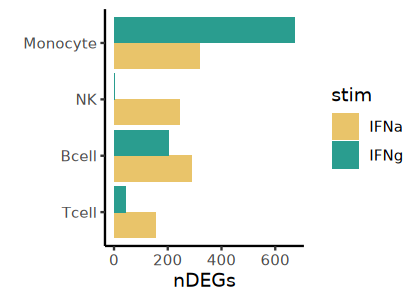

In [12]:
# separated by IFNa/g genes
fig.size(2.5,3.5)
#pdf(file.path(wd, "Figures", "Fig4", "IFNa_IFNg_L1_DEGs_Barplot.pdf"), height = 2.5, width = 3.5)
ggplot(data=degs_count, aes(x=celltype, y=n, fill=stim)) +
    geom_bar(stat="identity", position=position_dodge()) + 
    coord_flip() + 
    theme_classic() + 
    labs(x = "", y = "nDEGs") +
    scale_fill_manual(values=c("#e9c46a", "#2a9d8f"))
dev.off()

In [13]:
# counts by celltype only (number of unique IFNa/g genes)
degs_count <- degs %>% count(celltype) 

null device 
          1

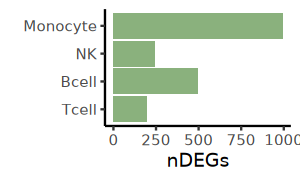

In [14]:
fig.size(1.5,2.5)
#pdf(file.path(wd, "Figures", "Fig4", "IFNa_IFNg_Unique_L1_DEGs_Barplot.pdf"), height = 1.5, width = 2.5)
ggplot(data=degs_count, aes(x=celltype, y=n)) +
    geom_bar(stat="identity", fill = '#8AB17D') + 
    coord_flip() + 
    theme_classic() + 
    labs(x = "", y = "nDEGs") 
dev.off()

### 4C/F. NDMM vs HC IFNa/g Scores Boxplot

In [23]:
score_df_long <- scores_df %>% 
                    pivot_longer(!c(celltype, Cohort, KitID, SubjectID, Misc), 
                                 names_to = "stim", values_to = "score") 
select_df <- score_df_long %>% filter(Cohort %in% c('BRI', 'MM_Pretreatment')) %>% na.omit()

Warning message in wilcox.test.default(c(0, 0, 0, 0.67698547614681, 0.133131303691693, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0.306067768248674, 0, 0, 0, 0, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0.740939818974752, 0, 0, 0, 0, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0, 0.800546419084286, 0, 0.350589463673638, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 67 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in wilcox.test.default(c(0, 0, 0, 0.0174611802399507, 0, 0.167700210493486, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.0190241678761912, 0.0488185647005405, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.221808472243655, 0.210835097575339, :
“cannot compute exact p

null device 
          1

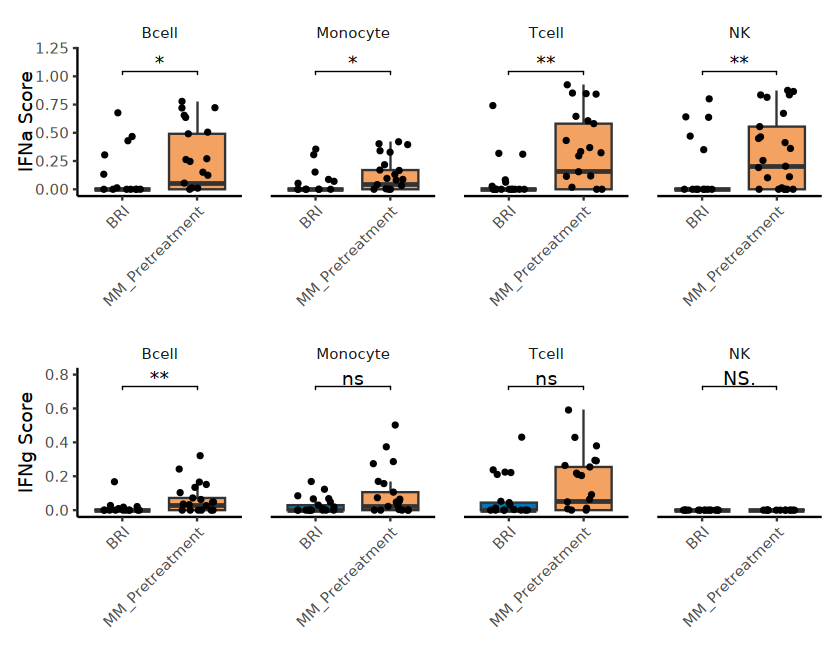

In [25]:
fig.size(5.5, 7)
#pdf(file.path(fig_dir, "Fig4", "BRI_NDMM_IFNa_IFNg_Score_Boxplot.pdf"), height = 5.5, width = 5)

# IFNa
gg1 <- ggplot(select_df %>% filter(stim == "IFNa"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 1.2) + 
    facet_wrap(~celltype, ncol = 4) + 
    scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNa Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",       # ← use stars instead of p-value
      size = 4,
      label.y = 1,
      comparisons = list(c("BRI", "MM_Pretreatment"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

# IFNg
gg2 <- ggplot(select_df %>% filter(stim == "IFNg"), aes(x = Cohort, y = score, fill = Cohort)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 0.8) + 
    facet_wrap(~celltype, ncol = 4) + 
    scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    xlab("") + 
    ylab("IFNg Score") + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",       # ← use stars instead of p-value
      size = 4,
      label.y = 0.7,
      comparisons = list(c("BRI", "MM_Pretreatment"))
    ) + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg1 / gg2
dev.off()

### 4D/E. NDMM vs HC IFNa/g MSD Boxplot

In [26]:
# read-in MSD results
msd <- fread(file.path(wd, "Cohort_IFN_scores", "MSD_results_Emma.csv"), header = T) %>% 
    filter(Status != "Control")

In [27]:
# format
msd_meta <- msd %>% left_join(meta %>% select(KitID, Misc, Cohort),
                                   by = c("KitID", "Cohort")) 

msd_meta$IFNa_Log2Conc <- log2(msd_meta$IFNa)
msd_meta$IFNb_Log2Conc <- log2(msd_meta$IFNb)
msd_meta$IFNg_Log2Conc <- log2(msd_meta$IFNg)
msd_meta[msd_meta == -Inf] <- 0

Warning message in wilcox.test.default(c(1.99313087142926, 2.50233060171601, -3.62593428177746, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(7.3662435196428, 4.35888851734327, 0, 3.95354462352481, :
“cannot compute exact p-value with ties”


null device 
          1

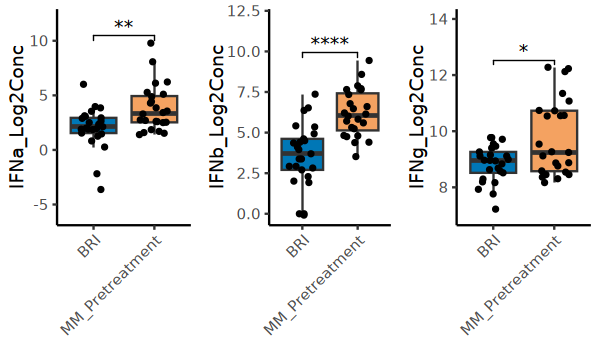

In [28]:
fig.size(3,5)
#pdf(file.path(fig_dir, "Fig4", "MM_Healthy_IFNa_IFNb_IFNg_Boxplots.pdf"), height = 3, width = 5.3)

ifns <- c("IFNa", "IFNb", "IFNg")
lims <- list(c(-6,12), c(-0.1,12), c(7,14))

ggs <- lapply(seq_along(ifns), function(i){
    stim_name <- glue("{ifns[i]}_Log2Conc")
    ggplot(msd_meta %>% filter(Cohort %in% c("BRI", "MM_Pretreatment")), aes(x = Cohort, y = !!sym(stim_name), fill = Cohort)) +
        #geom_line(aes(group = SubjectID), color = "gray70", size = 0.4, position = position_dodge(width = 0.25)) +
        geom_boxplot(outlier.shape = NA) + 
        geom_jitter(width = 0.25, size = 1) + 
        theme_classic() + 
        xlab("") + 
        ylab(stim_name) + 
        ylim(lims[[i]][1], lims[[i]][2]) + 
        scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
        stat_compare_means(method = "wilcox.test", label = "p.signif", 
                       size = 4, #label.y = 1,
                       comparisons = list(c("BRI", "MM_Pretreatment"))) +
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
              legend.position = "none",
              strip.background = element_blank(),
              panel.spacing = unit(1.2, "lines"))
    
    })
grid.arrange(grobs = ggs, ncol = 3)
dev.off()

### 4H/J. NDMM vs VrD IFNa/g Score Boxplots

In [29]:
# filter for pre and post treatment scores
mm_cohorts <- c("NDMM-VRd", "VRd", "NDMM-DVRd",  "DVRd")
select_df <- score_df_long %>% filter(Misc %in% mm_cohorts) #%>% na.omit()
select_df$Misc <- factor(select_df$Misc, levels = mm_cohorts)

Warning message in wilcox.test.default(c(0.270611937501346, 0.719830942821408, 0.65511242889348, :
“cannot compute exact p-value with zeroes”
Warning message in wilcox.test.default(c(0, 0, 0, 0.491208507511274, 0.246785184340969, :
“cannot compute exact p-value with zeroes”
Warning message in wilcox.test.default(c(0.217284691911577, 0.34116497752693, 0.166549635860562, :
“cannot compute exact p-value with zeroes”
Warning message in wilcox.test.default(c(0.170175381289749, 0, 0, 0.081031879384855, :
“cannot compute exact p-value with zeroes”
Warning message in wilcox.test.default(c(0.334059418427123, 0.851923887044417, 0.645671912561743, :
“cannot compute exact p-value with zeroes”
Warning message in wilcox.test.default(c(0.580962504176931, 0, 0, 0.368980243742655, :
“cannot compute exact p-value with zeroes”
Warning message in wilcox.test.default(c(0.254974102628612, 0.865866027207478, 0.814330180657479, :
“cannot compute exact p-value with zeroes”
Warning message in wilcox.test.defaul

null device 
          1

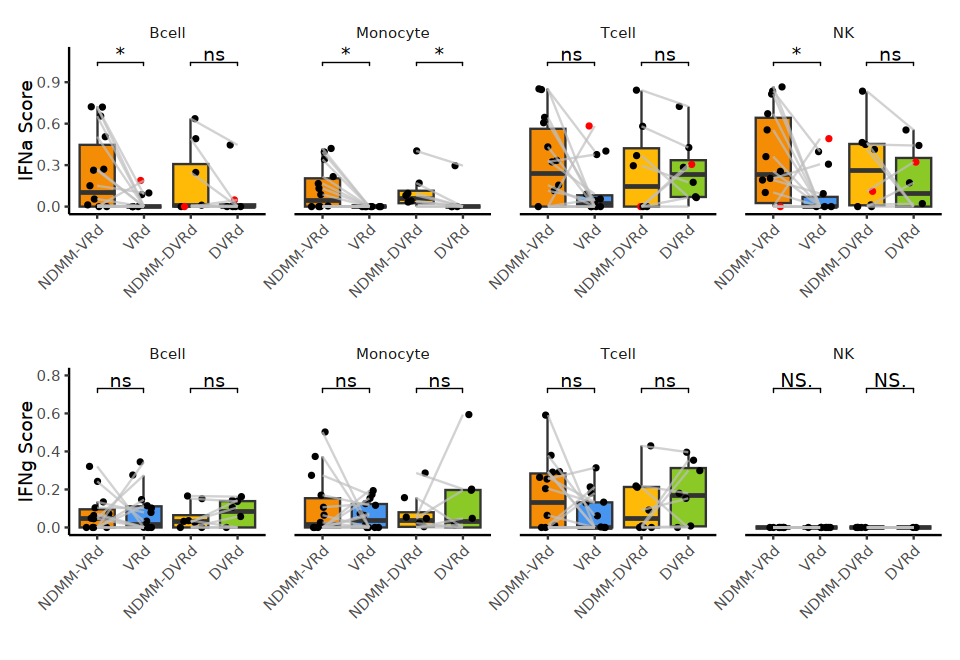

In [30]:
fig.size(5.5, 8)
#pdf(file.path(fig_dir, "Fig4", "NDMM-VRd_DVRd_IFNa_IFNg_Score_Boxplot.pdf"), height = 5.5, width = 7)

select_df_ifna <- select_df %>% filter(stim == "IFNa")
select_df_ifna$color <- ifelse(select_df_ifna$SubjectID %in% c("FH1018", "FH1021"), "red", "black")

gg1 <- ggplot(select_df_ifna, aes(x = Misc, y = score, fill = Misc)) +
    #geom_line(aes(group = SubjectID), color = "gray70", size = 0.4, position = position_dodge(width = 0.25)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(aes(color = ifelse(SubjectID %in% c("FH1018", "FH1021"), "red", "black")),
                width = 0.25, size = 1) + 
    ylim(0, 1.1) + 
    facet_wrap(~celltype, ncol = 4) + 
    scale_color_identity() + 
    # scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    geom_line(data = select_df_ifna %>% filter(Misc %in% c("NDMM-VRd", "VRd")),
            aes(group = SubjectID), color = "gray", linewidth = 0.5, alpha = 0.7) +
    # Add lines between Pre_DVRd and DVRd
    geom_line(data = select_df_ifna %>% filter(Misc %in% c("NDMM-DVRd", "DVRd")),
            aes(group = SubjectID), color = "gray", linewidth = 0.5, alpha = 0.7) +
    scale_fill_manual(values = c("#f48c06", "#4895ef", "#ffba08", "#8ac926")) + 
    xlab("") + 
    ylab("IFNa Score") + 
    stat_compare_means(method = "wilcox.test", label = "p.signif", paired = T,
                       size = 4, label.y = 1,
                       comparisons = list(c("NDMM-VRd", "VRd"), c("NDMM-DVRd", "DVRd"))) +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

select_df_ifng <- select_df %>% filter(stim == "IFNg")
gg2 <- ggplot(select_df_ifng, aes(x = Misc, y = score, fill = Misc)) +
    #geom_line(aes(group = SubjectID), color = "gray70", size = 0.4, position = position_dodge(width = 0.25)) +
    geom_boxplot(outlier.shape = NA) + 
    geom_jitter(width = 0.25, size = 1) + 
    ylim(0, 0.8) + 
    facet_wrap(~celltype, ncol = 4) + 
    # scale_fill_manual(values = c("#0077b6", "#f4a261")) + 
    theme_classic() + 
    geom_line(data = select_df_ifng %>% filter(Misc %in% c("NDMM-VRd", "VRd")),
            aes(group = SubjectID), color = "gray", linewidth = 0.5, alpha = 0.7) +
    # Add lines between Pre_DVRd and DVRd
    geom_line(data = select_df_ifng %>% filter(Misc %in% c("NDMM-DVRd", "DVRd")),
            aes(group = SubjectID), color = "gray", linewidth = 0.5, alpha = 0.7) +
    scale_fill_manual(values = c("#f48c06", "#4895ef", "#ffba08", "#8ac926")) + 
    xlab("") + 
    ylab("IFNg Score") + 
    stat_compare_means(method = "wilcox.test", label = "p.signif", paired = T,
                       size = 4, label.y = 0.7,
                       comparisons = list(c("NDMM-VRd", "VRd"), c("NDMM-DVRd", "DVRd"))) +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg1 / gg2
dev.off()

### 4I/K. NDMM vs VrD IFNa/g MSD Boxplots

In [31]:
pre_post_vars <- c("NDMM-VRd", "VRd", "NDMM-DVRd", "DVRd")

In [32]:
msd_meta_select <- msd_meta %>% filter(Misc %in% pre_post_vars)
msd_meta_select$Misc <- factor(msd_meta_select$Misc, pre_post_vars)

null device 
          1

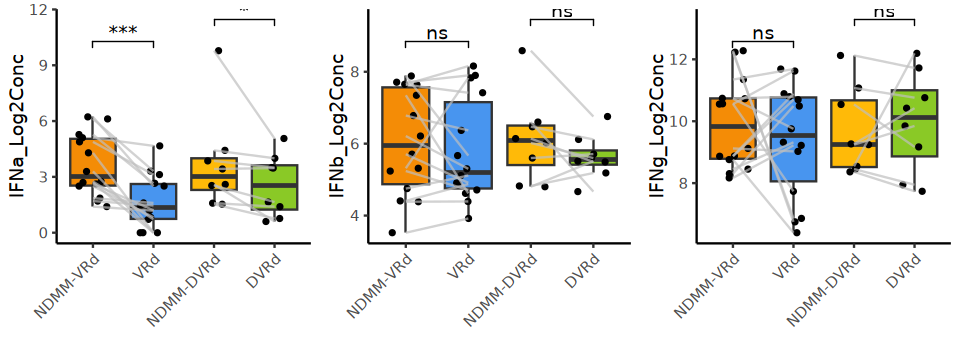

In [33]:
fig.size(3, 8)
#pdf(file.path(fig_dir, "Fig5", "NDMM-Vrd_IFNa_IFNb_IFNg_Boxplots.pdf"), height = 2.8, width = 7)

ggs <- lapply(ifns, function(i){
    stim_name <- glue("{i}_Log2Conc")
    ggplot(msd_meta_select, aes(x = Misc, y = !!sym(stim_name), fill = Misc)) +
        #geom_line(aes(group = SubjectID), color = "gray70", size = 0.4, position = position_dodge(width = 0.25)) +
        geom_boxplot(outlier.shape = NA) + 
        geom_jitter(size = 1, width = 0.25) + 
        
        theme_classic() + 
        geom_line(data = msd_meta_select %>% filter(Misc %in% c("NDMM-VRd", "VRd")),
                aes(group = SubjectID), color = "gray", linewidth = 0.5, alpha = 0.7) +
        # Add lines between Pre_DVRd and DVRd
        geom_line(data = msd_meta_select %>% filter(Misc %in% c("NDMM-DVRd", "DVRd")),
                aes(group = SubjectID), color = "gray", linewidth = 0.5, alpha = 0.7) +
        stat_compare_means(method = "wilcox.test", label = "p.signif", paired = T,
                       size = 4, #label.y = 1,
                       comparisons = list(c("NDMM-VRd", "VRd"), c("NDMM-DVRd", "DVRd"))) +
        scale_fill_manual(values = c("#f48c06", "#4895ef", "#ffba08", "#8ac926")) + 
        xlab("") + 
        ylab(stim_name) + 
        theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
              legend.position = "none",
              strip.background = element_blank(),
              panel.spacing = unit(1.2, "lines"))
    })
grid.arrange(grobs = ggs, ncol = 3)
dev.off()